# Exploratory Data Analysis (EDA)

## EV Charging Station Overload Prediction

### Objectives

The objective of this notebook is to understand the characteristics of the cleaned EV charging station dataset, identify patterns, detect anomalies, and derive insights that will assist in feature engineering and model development.

In [74]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [75]:
delhi_df = pd.read_csv("../data/processed/delhi_preprocessed.csv")

In [76]:
delhi_df.head()

,uid,name,vendor_name,address,latitude,longitude,open,close,staff,postal_code,zone,available,capacity,cost_per_unit,power_type,total,charger_type,vehicle_type,supports_upi,supports_cash,supports_card,supports_wallet
0,STATIC12,GensolCharge Pvt. Ltd.,GensolCharge Pvt. Ltd.,"NDSE Grid, BRPL South Extension",28.568238,77.219666,00:00:00,23:59:59,0,110001,central delhi,2.0,15.0,0.0,DC,2.0,DC001,['4W'],1,0,1,1
1,STATIC14,REIL,REIL,Scada office kalka ji,28.541995,77.260583,00:00:00,23:59:59,0,110001,central delhi,3.0,3.3,0.0,AC,3.0,AC001,"['2W', '3W', '4W']",0,0,0,1
2,STATIC15,REIL,REIL,Ashram Chowk Mathura Road,28.571189,77.259806,00:00:00,23:59:59,0,110001,central delhi,2.0,15.0,0.0,DC,2.0,DC001,['4W'],0,0,0,1
3,STATIC16,REIL,REIL,Nizamuddin Railway station,28.588991,77.253240,00:00:00,23:59:59,0,110001,central delhi,4.0,15.0,0.0,DC,4.0,DC001,['4W'],0,1,0,1
4,STATIC17,BluSmart,BluSmart,"BSES Bhawan, Nehru Place, New Delhi 110048",28.549427,77.254636,00:00:00,23:59:59,0,110001,central delhi,1.0,15.0,0.0,DC,1.0,DC001,['4W'],0,1,0,1


In [77]:
delhi_df.shape
delhi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2229 entries, 0 to 2228
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   uid              2229 non-null   str    
 1   name             2229 non-null   str    
 2   vendor_name      2229 non-null   str    
 3   address          2229 non-null   str    
 4   latitude         2229 non-null   float64
 5   longitude        2229 non-null   float64
 6   open             2229 non-null   str    
 7   close            2229 non-null   str    
 8   staff            2229 non-null   int64  
 9   postal_code      2229 non-null   int64  
 10  zone             2229 non-null   str    
 11  available        2229 non-null   float64
 12  capacity         2229 non-null   float64
 13  cost_per_unit    2229 non-null   float64
 14  power_type       2229 non-null   str    
 15  total            2229 non-null   float64
 16  charger_type     2229 non-null   str    
 17  vehicle_type     2229 non

In [78]:

delhi_df.describe()

,latitude,longitude,staff,postal_code,available,capacity,cost_per_unit,total,supports_upi,supports_cash,supports_card,supports_wallet
count,2229.000000,2229.000000,2229.000000,2229.000000,2229.00000,2229.000000,2229.000000,2229.000000,2229.000000,2229.000000,2229.000000,2229.000000
mean,27.875922,77.050735,0.024675,110051.857335,1.07223,9.924989,2.205034,1.149843,0.838941,0.084791,0.011216,0.166442
std,3.028099,4.017268,0.155167,34.798810,1.11449,25.482888,5.582466,1.118626,0.367668,0.278634,0.105333,0.372561
min,0.000000,0.000000,0.000000,110001.000000,0.00000,3.300000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,28.556311,77.100000,0.000000,110030.000000,1.00000,3.300000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,28.614395,77.191008,0.000000,110053.000000,1.00000,3.300000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,28.679547,77.266684,0.000000,110074.000000,1.00000,3.300000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,28.861556,78.504526,1.000000,110503.000000,40.00000,142.000000,31.000000,40.000000,1.000000,1.000000,1.000000,1.000000


In [79]:

delhi_df.describe(include="object")

C:\Users\mitta\AppData\Local\Temp\ipykernel_21088\3525249758.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  delhi_df.describe(include="object")


,uid,name,vendor_name,address,open,close,zone,power_type,charger_type,vehicle_type
count,2229,2229,2229,2229,2229,2229,2229,2229,2229,2229
unique,2085,120,19,1427,5,5,9,3,10,3
top,EESL1161,REVOS,REVOS,Delhi,00:00:00,00:00:00,south west delhi,AC,5A/15A Socket,"['2W', '3W']"
freq,5,1858,1858,228,2033,1858,631,1989,1857,1857


In [80]:
delhi_df.isnull().sum()

uid                0
name               0
vendor_name        0
address            0
latitude           0
longitude          0
open               0
close              0
staff              0
postal_code        0
zone               0
available          0
capacity           0
cost_per_unit      0
power_type         0
total              0
charger_type       0
vehicle_type       0
supports_upi       0
supports_cash      0
supports_card      0
supports_wallet    0
dtype: int64

In [81]:
delhi_df.duplicated().sum()

np.int64(0)

In [82]:
delhi_df["zone"].value_counts()

zone
south west delhi    631
south delhi         365
west delhi          304
east delhi          276
north west delhi    264
central delhi       207
north delhi         140
north east delhi     39
south east delhi      3
Name: count, dtype: int64

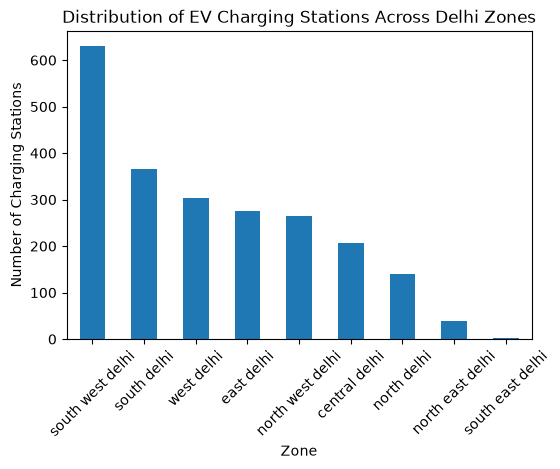

In [83]:

zone_counts = delhi_df["zone"].value_counts()

plt.figure(figsize=(6, 4))
zone_counts.plot(kind="bar")

plt.title("Distribution of EV Charging Stations Across Delhi Zones")
plt.xlabel("Zone")
plt.ylabel("Number of Charging Stations")
plt.xticks(rotation=45)

plt.show()

### Observations

- South West Delhi has the highest number of EV charging stations (631).
- South Delhi (365) and West Delhi (304) also have a high concentration of charging stations.
- North East Delhi has only 39 charging stations, while South East Delhi has just 3.
- The charging infrastructure is unevenly distributed across different zones of Delhi.
- Zones with fewer charging stations may experience higher demand per station, making them potential candidates for overload analysis.

In [84]:
delhi_df["uid"].value_counts()

uid
EESL1161            5
1160                5
1161                5
EESL422             4
EESL428             4
                   ..
421                 1
1383                1
443                 1
WMQISXM1V1-00268    1
ElectriVa04         1
Name: count, Length: 2085, dtype: int64

In [85]:
delhi_df["uid"].duplicated().sum()

np.int64(144)

In [86]:
delhi_df[delhi_df["uid"]=="1160"]

,uid,name,vendor_name,address,latitude,longitude,open,close,staff,postal_code,zone,available,capacity,cost_per_unit,power_type,total,charger_type,vehicle_type,supports_upi,supports_cash,supports_card,supports_wallet
2184,1160,EESL - DTC IP Depot,EESL,"CESL - DTC EV Plaza, IP DTC Depot, New Delhi -...",28.620105,77.247931,00:00,23:59,0,110503,central delhi,1.0,142.0,23.0,AC,1.0,Type 2,['4W'],0,0,0,1
2185,1160,EESL - DTC IP Depot,EESL,"CESL - DTC EV Plaza, IP DTC Depot, New Delhi -...",28.620105,77.247931,00:00,23:59,0,110503,central delhi,1.0,15.0,10.0,DC,1.0,DC001,['4W'],0,0,0,1
2186,1160,EESL - DTC IP Depot,EESL,"CESL - DTC EV Plaza, IP DTC Depot, New Delhi -...",28.620105,77.247931,00:00,23:59,0,110503,central delhi,1.0,142.0,23.0,DC,1.0,CCS2,['4W'],0,0,0,1
2187,1160,EESL - DTC IP Depot,EESL,"CESL - DTC EV Plaza, IP DTC Depot, New Delhi -...",28.620105,77.247931,00:00,23:59,0,110503,central delhi,1.0,142.0,23.0,DC,1.0,CHAdeMO,['4W'],0,0,0,1
2188,1160,EESL - DTC IP Depot,EESL,"CESL - DTC EV Plaza, IP DTC Depot, New Delhi -...",28.620105,77.247931,00:00,23:59,0,110503,central delhi,3.0,9.9,1.6,AC,3.0,AC001,"['2W', '3W', '4W']",0,0,0,1


## UID Analysis

The `uid` field was analyzed for duplicate entries.

Although 144 duplicate `uid` values were found, further inspection showed that these records correspond to the same charging station with different charger types. Therefore, the repeated `uid` values are expected and were retained in the dataset.

In [87]:
delhi_df["charger_type"].value_counts()

charger_type
5A/15A Socket             1857
DC001                      150
Type 2                      68
CCS2                        48
AC001                       39
CHAdeMO                     39
battery_swapping            25
CCS2/CHADEMO/TYPE 2 AC       1
CCS/ CHAdeMO                 1
DC                           1
Name: count, dtype: int64

In [88]:
pd.crosstab(
    delhi_df["charger_type"],
    delhi_df["power_type"]
)

power_type,AC,AC/DC,DC
charger_type,,,
5A/15A Socket,1857,0,0
AC001,39,0,0
CCS/ CHAdeMO,0,0,1
CCS2,0,0,48
CCS2/CHADEMO/TYPE 2 AC,0,1,0
CHAdeMO,0,0,39
DC,0,0,1
DC001,0,0,150
Type 2,68,0,0


In [89]:
delhi_df[
    delhi_df["charger_type"] == "CCS-2"
][[
    "uid",
    "name",
    "power_type",
    "capacity",
    "vendor_name"
]]

,uid,name,power_type,capacity,vendor_name


In [90]:
delhi_df.loc[2059]

uid                                                       ElectriVa1
name               Rajouri garden market ( B.K DUTTA MARKET ) - C...
vendor_name                                                ElectriVa
address            J2, 8, Block J, Rajouri Garden, New Delhi, Del...
latitude                                                   28.647521
longitude                                                  77.119354
open                                                        00:00:00
close                                                       23:59:59
staff                                                              0
postal_code                                                   110027
zone                                                      west delhi
available                                                        2.0
capacity                                                        30.0
cost_per_unit                                                   15.0
power_type                        

In [91]:
delhi_df.loc[2059, "power_type"] = "DC"

In [92]:
pd.crosstab(
    delhi_df["charger_type"],
    delhi_df["power_type"]
)

power_type,AC,AC/DC,DC
charger_type,,,
5A/15A Socket,1857,0,0
AC001,39,0,0
CCS/ CHAdeMO,0,0,1
CCS2,0,0,48
CCS2/CHADEMO/TYPE 2 AC,0,1,0
CHAdeMO,0,0,39
DC,0,0,1
DC001,0,0,150
Type 2,68,0,0


In [93]:
delhi_df[
    delhi_df["charger_type"] == "CCS2/CHADEMO/TYPE 2 AC"
]

,uid,name,vendor_name,address,latitude,longitude,open,close,staff,postal_code,zone,available,capacity,cost_per_unit,power_type,total,charger_type,vehicle_type,supports_upi,supports_cash,supports_card,supports_wallet
23,STATIC38,PlugNgo,PlugNgo,"Plug & Go, Near Swati Appt, Narwana Road, Patp...",28.6215,77.2935,08:00:00,20:00:00,1,110001,central delhi,1.0,142.0,0.0,AC/DC,1.0,CCS2/CHADEMO/TYPE 2 AC,['4W'],0,0,0,1


In [94]:
delhi_df[
    delhi_df["charger_type"] == "DC001"
]

,uid,name,vendor_name,address,latitude,longitude,open,close,staff,postal_code,zone,available,capacity,cost_per_unit,power_type,total,charger_type,vehicle_type,supports_upi,supports_cash,supports_card,supports_wallet
0,STATIC12,GensolCharge Pvt. Ltd.,GensolCharge Pvt. Ltd.,"NDSE Grid, BRPL South Extension",28.568238,77.219666,00:00:00,23:59:59,0,110001,central delhi,2.0,15.0,0.0,DC,2.0,DC001,['4W'],1,0,1,1
2,STATIC15,REIL,REIL,Ashram Chowk Mathura Road,28.571189,77.259806,00:00:00,23:59:59,0,110001,central delhi,2.0,15.0,0.0,DC,2.0,DC001,['4W'],0,0,0,1
3,STATIC16,REIL,REIL,Nizamuddin Railway station,28.588991,77.253240,00:00:00,23:59:59,0,110001,central delhi,4.0,15.0,0.0,DC,4.0,DC001,['4W'],0,1,0,1
4,STATIC17,BluSmart,BluSmart,"BSES Bhawan, Nehru Place, New Delhi 110048",28.549427,77.254636,00:00:00,23:59:59,0,110001,central delhi,1.0,15.0,0.0,DC,1.0,DC001,['4W'],0,1,0,1
6,STATIC19,EEE,EEE,"Mukteshwar dham Andheriya bagh,mehrauli",28.510291,77.171653,00:00:00,23:59:59,0,110001,central delhi,7.0,15.0,0.0,DC,7.0,DC001,['4W'],0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2205,421,EESL Charak Palika H,EESL,"NDMC Parking, Charak Palika Hospital, C 7 Lan...",28.585367,77.177550,00:00,23:59,0,110021,south west delhi,2.0,15.0,10.0,DC,2.0,DC001,['4W'],0,0,0,1
2207,443,EESL Talkatora Stadi,EESL,Talkatora Stadium Presidents Estate New Delhi ...,28.625753,77.194530,00:00,23:59,0,110004,central delhi,1.0,15.0,9.5,DC,2.0,DC001,['4W'],0,0,0,1
2208,579,EESL R block GK1,EESL,"SDMC Parking, R Block, GK-1, DELHI-110016",28.547217,77.244324,00:00,23:59,0,110016,south west delhi,1.0,15.0,10.0,DC,1.0,DC001,['4W'],0,0,0,1
2218,1283,EESL NDMC Barat Ghar,EESL,"NDMC Barat Ghar - Moti Bagh, E Block, Moti Bag...",28.583150,77.180980,00:00,23:59,0,110021,south west delhi,0.0,60.0,10.0,DC,1.0,DC001,['4W'],0,0,0,1


In [95]:
delhi_df.loc[2048, "power_type"] = "DC"

In [96]:
delhi_df[
    delhi_df["charger_type"] == "IEC-62196-T2"
]

,uid,name,vendor_name,address,latitude,longitude,open,close,staff,postal_code,zone,available,capacity,cost_per_unit,power_type,total,charger_type,vehicle_type,supports_upi,supports_cash,supports_card,supports_wallet


In [97]:
delhi_df[
    delhi_df["charger_type"] == "IEC-62196-T2-COMBO"
]

,uid,name,vendor_name,address,latitude,longitude,open,close,staff,postal_code,zone,available,capacity,cost_per_unit,power_type,total,charger_type,vehicle_type,supports_upi,supports_cash,supports_card,supports_wallet


In [98]:
delhi_df[
    delhi_df["charger_type"] == "DC"
]

,uid,name,vendor_name,address,latitude,longitude,open,close,staff,postal_code,zone,available,capacity,cost_per_unit,power_type,total,charger_type,vehicle_type,supports_upi,supports_cash,supports_card,supports_wallet
2020,pbdtl201,DMRC Hauz Khas Parking,Powerbank,"Sri Krishna Chaitanya Mahaprabhu Marg, Block F...",28.54488,77.20691,00:00:00,23:59:59,0,110016,south west delhi,2.0,30.0,21.0,DC,2.0,DC,['4W'],0,0,0,1


In [99]:
delhi_df["charger_type"] = delhi_df["charger_type"].replace({
    "TYPE - 2 (AC)": "Type 2",
    "TYPE - 2": "Type 2",
    "TYPE 2 AC": "Type 2",
    "AC Type 2": "Type 2",
    "Type 2 Plug": "Type 2",
    "T2": "Type 2",
    "IEC-62196-T2": "Type 2",

    "CHAdeMO (DC)": "CHAdeMO",
    "CHADEMO": "CHAdeMO",

    "DC-001": "DC001",
    "BEVC DC 001": "DC001",
    "EVRE DC001": "DC001",

    "BEVC-AC001": "AC001",
    "BEVC AC 001": "AC001",
    "EVRE AC001": "AC001",

    "CCS (DC)": "CCS",
    "CCS-2": "CCS2",
    "IEC-62196-T2-COMBO": "CCS2",
    "CCS": "CCS2"
})

In [100]:
pd.crosstab(
    delhi_df["charger_type"],
    delhi_df["power_type"]
)

power_type,AC,AC/DC,DC
charger_type,,,
5A/15A Socket,1857,0,0
AC001,39,0,0
CCS/ CHAdeMO,0,0,1
CCS2,0,0,48
CCS2/CHADEMO/TYPE 2 AC,0,1,0
CHAdeMO,0,0,39
DC,0,0,1
DC001,0,0,150
Type 2,68,0,0


In [101]:
delhi_df.loc[
    delhi_df["charger_type"] == "CCS2/CHADEMO/TYPE 2 AC",
    "power_type"
] = "AC/DC"


In [102]:
pd.crosstab(
    delhi_df["charger_type"],
    delhi_df["power_type"]
)

power_type,AC,AC/DC,DC
charger_type,,,
5A/15A Socket,1857,0,0
AC001,39,0,0
CCS/ CHAdeMO,0,0,1
CCS2,0,0,48
CCS2/CHADEMO/TYPE 2 AC,0,1,0
CHAdeMO,0,0,39
DC,0,0,1
DC001,0,0,150
Type 2,68,0,0


In [103]:
delhi_df.to_csv("../data/processed/delhi_preprocessed.csv", index=False)

In [104]:
delhi_df["charger_type"].value_counts()

charger_type
5A/15A Socket             1857
DC001                      150
Type 2                      68
CCS2                        48
AC001                       39
CHAdeMO                     39
battery_swapping            25
CCS2/CHADEMO/TYPE 2 AC       1
CCS/ CHAdeMO                 1
DC                           1
Name: count, dtype: int64

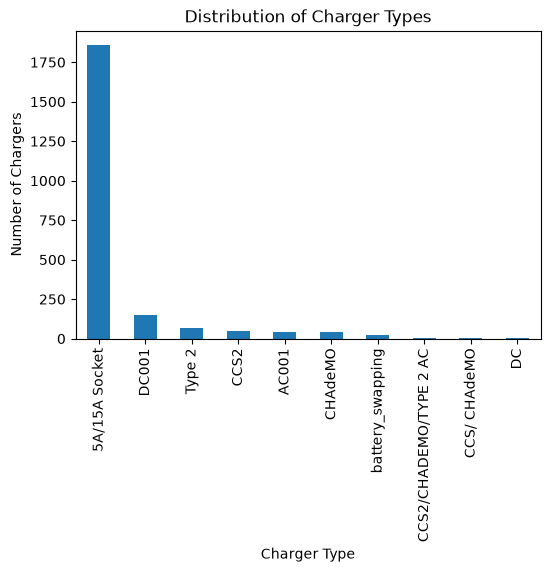

In [105]:
plt.figure(figsize=(6,4))

delhi_df["charger_type"].value_counts().plot(kind="bar")

plt.title("Distribution of Charger Types")
plt.xlabel("Charger Type")
plt.ylabel("Number of Chargers")
plt.xticks(rotation=90)

plt.show()

In [106]:
(
    delhi_df["charger_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

charger_type
5A/15A Socket             83.31
DC001                      6.73
Type 2                     3.05
CCS2                       2.15
AC001                      1.75
CHAdeMO                    1.75
battery_swapping           1.12
CCS2/CHADEMO/TYPE 2 AC     0.04
CCS/ CHAdeMO               0.04
DC                         0.04
Name: proportion, dtype: float64

### Observations

- The dataset is dominated by **5A/15A Socket** chargers (1857 charging points), representing the majority of the available infrastructure.
- **DC001** is the second most common charger type, followed by **Type 2**, **CCS2**, **AC001**, and **CHAdeMO**.
- Fast DC charging standards (CCS2, CHAdeMO, and DC001) are available but are much less common than standard AC charging sockets.
- Battery swapping stations are present but account for only a small portion of the dataset.
- A few charging stations support multiple connector types (e.g., CCS2/CHAdeMO/Type 2 AC), indicating multi-standard charging facilities.

### Objective
To analyze the distribution of AC, DC, and AC/DC charging stations.

In [107]:
delhi_df["power_type"].value_counts()

power_type
AC       1989
DC        239
AC/DC       1
Name: count, dtype: int64

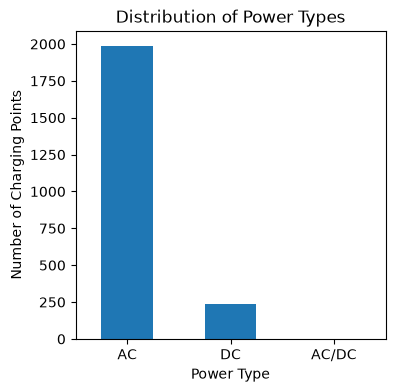

In [108]:
plt.figure(figsize=(4,4))

delhi_df["power_type"].value_counts().plot(kind="bar")

plt.title("Distribution of Power Types")
plt.xlabel("Power Type")
plt.ylabel("Number of Charging Points")
plt.xticks(rotation=0)

plt.show()

In [109]:
(
    delhi_df["power_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

power_type
AC       89.23
DC       10.72
AC/DC     0.04
Name: proportion, dtype: float64

In [110]:
delhi_df["vehicle_type"].value_counts()

vehicle_type
['2W', '3W']          1857
['4W']                 333
['2W', '3W', '4W']      39
Name: count, dtype: int64

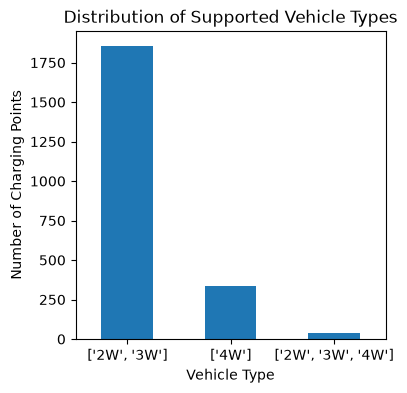

In [111]:
plt.figure(figsize=(4,4))

delhi_df["vehicle_type"].value_counts().plot(kind="bar")

plt.title("Distribution of Supported Vehicle Types")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Charging Points")
plt.xticks(rotation=0)

plt.show()

In [112]:
(
    delhi_df["vehicle_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

vehicle_type
['2W', '3W']          83.31
['4W']                14.94
['2W', '3W', '4W']     1.75
Name: proportion, dtype: float64

### Observations

- The majority of charging points (1,857) support both electric two-wheelers and three-wheelers.
- A total of 333 charging points are dedicated exclusively to four-wheelers.
- Only 39 charging points support all three vehicle categories (2W, 3W, and 4W).
- The dataset indicates that charging infrastructure for two- and three-wheelers is more prevalent than dedicated four-wheeler charging infrastructure.


## Capacity Analysis

### Objective

To analyze the distribution of charger capacities across EV charging stations and identify the most commonly deployed charging capacities.

In [113]:
delhi_df["capacity"].value_counts()

capacity
3.3      1872
15.0      151
142.0      75
22.0       37
7.0        19
26.0       16
9.9        16
56.0       16
28.0        9
10.0        8
30.0        4
7.4         2
20.0        1
50.0        1
16.0        1
60.0        1
Name: count, dtype: int64

In [114]:
delhi_df["capacity"].dtype

dtype('float64')

In [115]:
delhi_df["capacity"].value_counts().sort_index()

capacity
3.3      1872
7.0        19
7.4         2
9.9        16
10.0        8
15.0      151
16.0        1
20.0        1
22.0       37
26.0       16
28.0        9
30.0        4
50.0        1
56.0       16
60.0        1
142.0      75
Name: count, dtype: int64

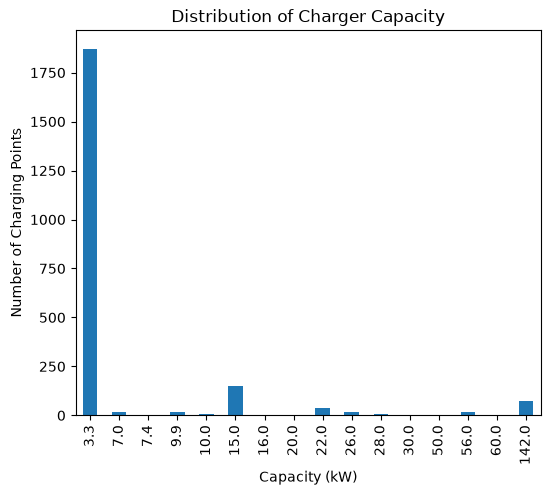

In [116]:
plt.figure(figsize=(6,5))

delhi_df["capacity"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Charger Capacity")
plt.xlabel("Capacity (kW)")
plt.ylabel("Number of Charging Points")
plt.xticks(rotation=90)
plt.show()

### Observations

- Charger capacities range from low-capacity chargers (3.3 kW) to high-capacity fast chargers (142 kW).
- Most charging stations have a capacity of **3.3 kW**, indicating that lower-capacity chargers dominate the dataset.
- High-capacity chargers such as 60 kW and 142 kW are comparatively rare.
- The wide range of charger capacities suggests that the dataset includes both standard charging points and fast-charging infrastructure.

In [117]:
delhi_df["cost_per_unit"].describe()

count    2229.000000
mean        2.205034
std         5.582466
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        31.000000
Name: cost_per_unit, dtype: float64

In [118]:
delhi_df["cost_per_unit"].value_counts().sort_index()

cost_per_unit
0.00     1843
1.60        8
2.00        1
2.05       45
2.73        4
2.85        3
5.00        4
6.50        1
8.00        1
9.50       36
10.00     109
11.00       3
12.00       4
13.00       1
15.00      30
16.00       3
18.00       2
19.00      83
20.00      12
21.00       1
23.00      24
25.00       4
26.00       2
30.00       3
31.00       2
Name: count, dtype: int64

In [119]:
pd.crosstab(
    delhi_df["vendor_name"],
    delhi_df["cost_per_unit"]
)

cost_per_unit,0.00,1.60,2.00,2.05,2.73,2.85,5.00,6.50,8.00,9.50,10.00,11.00,12.00,13.00,15.00,16.00,18.00,19.00,20.00,21.00,23.00,25.00,26.00,30.00,31.00
vendor_name,,,,,,,,,,,,,,,,,,,,,,,,,
BLUSMART,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
BSES,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
BluSmart,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
E-Fill Electric,0,0,0,0,0,0,0,0,0,0,0,0,0,0,18,0,0,0,0,0,0,0,0,0,0
EEE,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
EESL,0,8,0,0,0,0,0,0,0,36,109,0,0,0,0,0,0,82,0,0,24,0,2,0,0
ElectriVa,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0
GensolCharge Pvt. Ltd.,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
HPCL,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


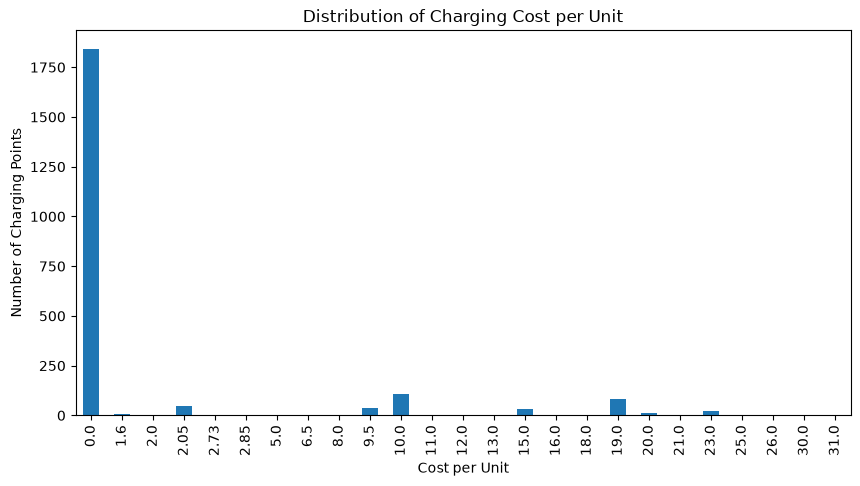

In [120]:
plt.figure(figsize=(10,5))

delhi_df["cost_per_unit"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Charging Cost per Unit")
plt.xlabel("Cost per Unit")
plt.ylabel("Number of Charging Points")
plt.xticks(rotation=90)

plt.show()

### Observations

- The majority of charging stations (1843) have a charging cost of ₹0.00 per unit.
- This pattern is primarily driven by **REVOS**, which contributes 1813 of the free charging stations in the dataset.
- EESL follows a structured pricing model, with most stations charging ₹10.00, ₹19.00, ₹9.50, or ₹23.00 per unit.
- Several vendors appear to follow fixed pricing strategies, while others have only a small number of charging stations.
- Charging costs range from ₹0.00 to ₹31.00 per unit, indicating variation in pricing across different charging networks.

## Available vs Total Chargers

### Objective

To analyze the distribution of available and total charging points across EV charging stations and understand station capacity.

In [121]:
delhi_df[["available", "total"]].describe()

,available,total
count,2229.00000,2229.000000
mean,1.07223,1.149843
std,1.11449,1.118626
min,0.00000,1.000000
25%,1.00000,1.000000
50%,1.00000,1.000000
75%,1.00000,1.000000
max,40.00000,40.000000


In [122]:
print("Available Chargers")
print(delhi_df["available"].value_counts().sort_index())

print("\nTotal Chargers")
print(delhi_df["total"].value_counts().sort_index())


Available Chargers
available
0.0       95
1.0     2016
2.0       89
3.0       11
4.0       10
7.0        2
12.0       3
13.0       1
20.0       1
40.0       1
Name: count, dtype: int64

Total Chargers
total
1.0     2059
2.0      121
3.0       29
4.0       10
6.0        2
7.0        2
12.0       3
13.0       1
20.0       1
40.0       1
Name: count, dtype: int64


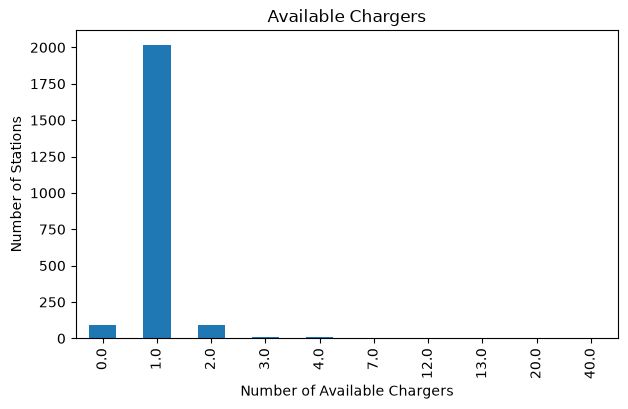

In [123]:
plt.figure(figsize=(7,4))

delhi_df["available"].value_counts().sort_index().plot(kind="bar")

plt.title("Available Chargers")
plt.xlabel("Number of Available Chargers")
plt.ylabel("Number of Stations")

plt.show()

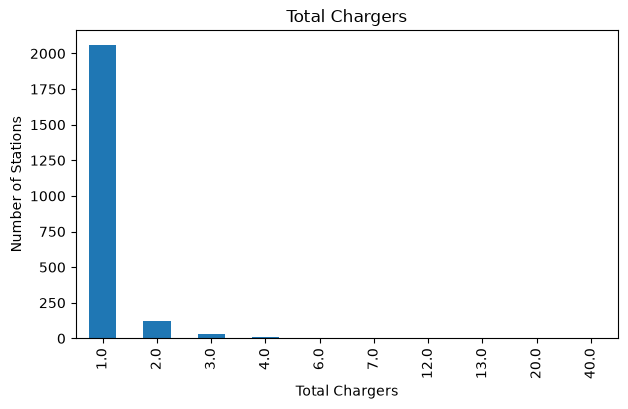

In [124]:
plt.figure(figsize=(7,4))

delhi_df["total"].value_counts().sort_index().plot(kind="bar")

plt.title("Total Chargers")
plt.xlabel("Total Chargers")
plt.ylabel("Number of Stations")

plt.show()

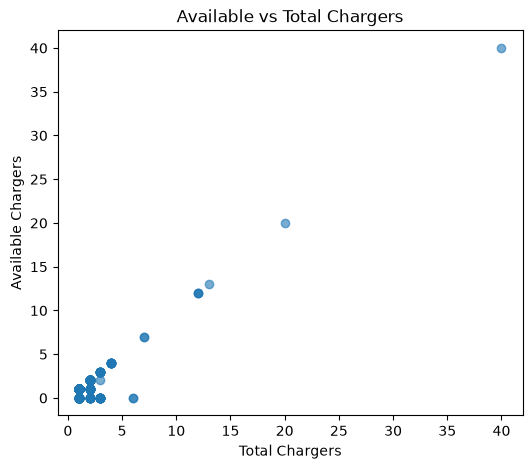

In [125]:
plt.figure(figsize=(6,5))

plt.scatter(
    delhi_df["total"],
    delhi_df["available"],
    alpha=0.6
)

plt.xlabel("Total Chargers")
plt.ylabel("Available Chargers")
plt.title("Available vs Total Chargers")

plt.show()

In [126]:
(delhi_df["available"] > delhi_df["total"]).sum()

np.int64(0)

In [127]:
(
    (delhi_df["available"] == delhi_df["total"]).mean() * 100
).round(2)

np.float64(94.75)

In [128]:
payment_cols = [
    "supports_upi",
    "supports_cash",
    "supports_card",
    "supports_wallet"
]

for col in payment_cols:
    print(f"\n{col}")
    print(delhi_df[col].value_counts())


supports_upi
supports_upi
1    1870
0     359
Name: count, dtype: int64

supports_cash
supports_cash
0    2040
1     189
Name: count, dtype: int64

supports_card
supports_card
0    2204
1      25
Name: count, dtype: int64

supports_wallet
supports_wallet
0    1858
1     371
Name: count, dtype: int64


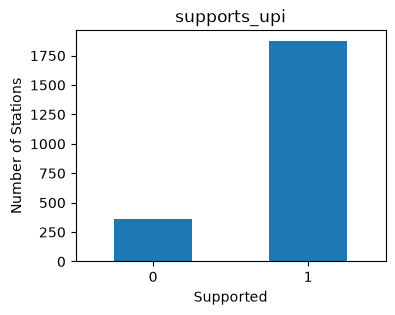

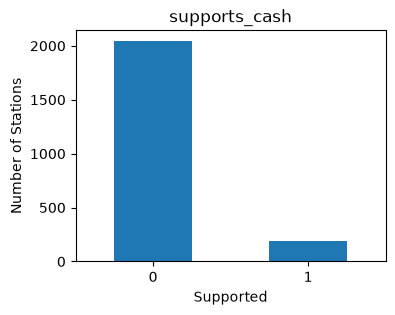

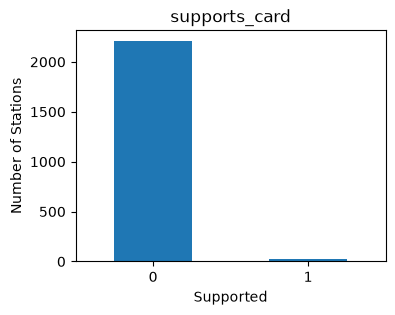

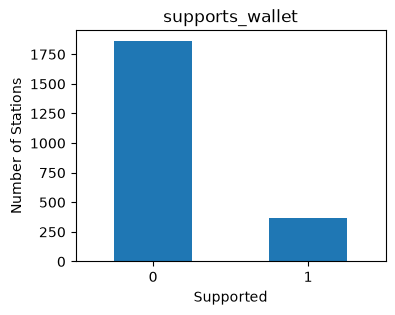

In [129]:
payment_cols = [
    "supports_upi",
    "supports_cash",
    "supports_card",
    "supports_wallet"
]

for col in payment_cols:
    plt.figure(figsize=(4,3))
    delhi_df[col].value_counts().sort_index().plot(kind="bar")
    plt.title(col)
    plt.xlabel("Supported")
    plt.ylabel("Number of Stations")
    plt.xticks(rotation=0)
    plt.show()

### Observations

- **UPI** is the most widely supported payment method, with **1,870** charging stations accepting UPI payments.
- **Digital wallets** are supported by **371** charging stations, making them the second most common payment option.
- **Cash payments** are accepted at only **189** charging stations, indicating limited support compared to digital payment methods.
- **Card payments** are the least supported payment option, with only **25** charging stations accepting card transactions.
- Overall, the dataset indicates a strong preference for **digital payment methods**, particularly UPI.

In [130]:
delhi_df["payment_methods"] = (
    delhi_df["supports_upi"] +
    delhi_df["supports_cash"] +
    delhi_df["supports_card"] +
    delhi_df["supports_wallet"]
)

In [131]:
delhi_df["payment_methods"].value_counts().sort_index()

payment_methods
1    2028
2     176
3      25
Name: count, dtype: int64

### Additional Observations

- Most charging stations (**2,028**) support only **one payment method**.
- **176** charging stations support **two payment methods**, providing greater payment flexibility.
- Only **25** charging stations support **three payment methods**.
- No charging station in the dataset supports all four payment methods simultaneously.

In [132]:
numeric_df = delhi_df.select_dtypes(include="number")

numeric_df.corr()

,latitude,longitude,staff,postal_code,available,capacity,cost_per_unit,total,supports_upi,supports_cash,supports_card,supports_wallet,payment_methods
latitude,1.000000,0.407394,0.038957,-0.102365,0.014650,0.061094,0.090007,0.031045,-0.104721,0.073494,0.027576,0.106897,0.073303
longitude,0.407394,1.000000,0.002590,-0.016316,0.001473,0.009044,0.013229,0.004240,-0.015293,0.009586,0.003075,0.015584,0.009430
staff,0.038957,0.002590,1.000000,-0.067509,0.257019,0.124910,-0.015040,0.245030,-0.363015,0.439509,-0.016940,0.355949,0.355514
postal_code,-0.102365,-0.016316,-0.067509,1.000000,-0.053861,-0.051038,-0.113903,-0.122362,0.246257,-0.210066,-0.035196,-0.260239,-0.203695
available,0.014650,0.001473,0.257019,-0.053861,1.000000,0.039970,0.008621,0.937801,-0.133709,0.117578,0.012213,0.145068,0.115519
capacity,0.061094,0.009044,0.124910,-0.051038,0.039970,1.000000,0.640216,0.134404,-0.585817,0.119445,0.003156,0.581754,0.103747
cost_per_unit,0.090007,0.013229,-0.015040,-0.113903,0.008621,0.640216,1.000000,0.114814,-0.716367,0.433700,0.164014,0.718081,0.422101
total,0.031045,0.004240,0.245030,-0.122362,0.937801,0.134404,0.114814,1.000000,-0.291602,0.216981,0.004776,0.299837,0.194210
supports_upi,-0.104721,-0.015293,-0.363015,0.246257,-0.133709,-0.585817,-0.716367,-0.291602,1.000000,-0.694687,-0.161947,-0.980533,-0.617923
supports_cash,0.073494,0.009586,0.439509,-0.210066,0.117578,0.119445,0.433700,0.216981,-0.694687,1.000000,0.242854,0.681164,0.897753


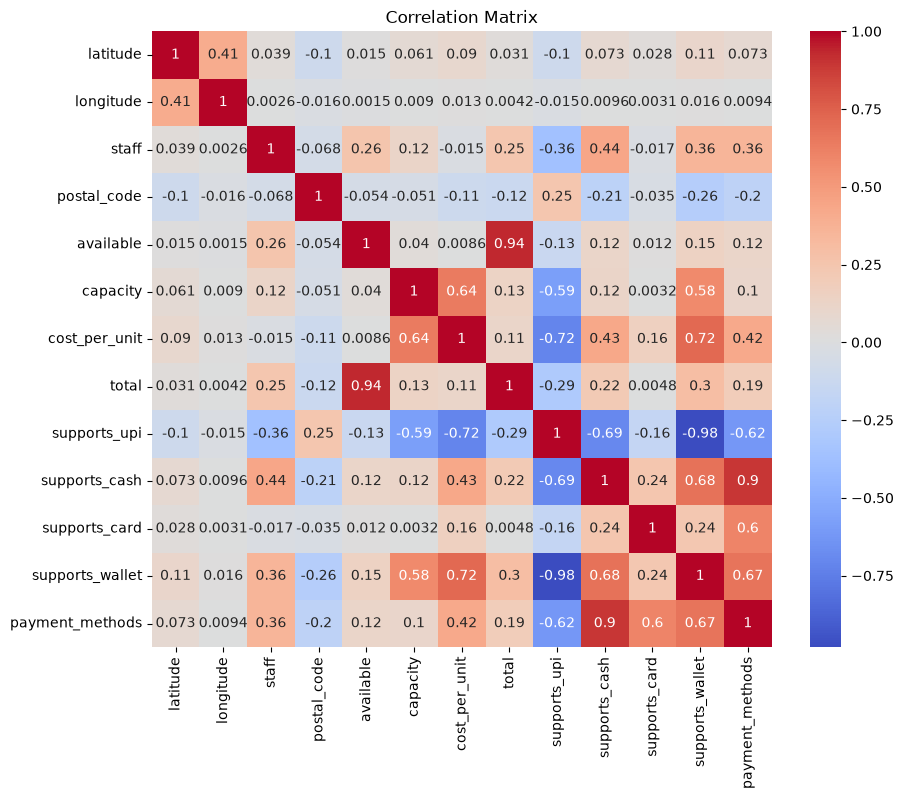

In [133]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

### Observations

- **Available chargers** and **total chargers** exhibit a very strong positive correlation (0.94), indicating that stations with more charging points generally have more chargers available.
- **Capacity** and **cost per unit** show a moderate positive correlation (0.64), suggesting that higher-capacity chargers tend to have higher charging costs.
- The payment-related features exhibit strong correlations because they describe different aspects of the same payment system. In particular, `payment_methods` is derived from the supported payment options, leading to naturally high correlations.
- Most geographic features (latitude, longitude, and postal code) show weak correlations with operational attributes, indicating that location alone does not strongly explain charger capacity or pricing.

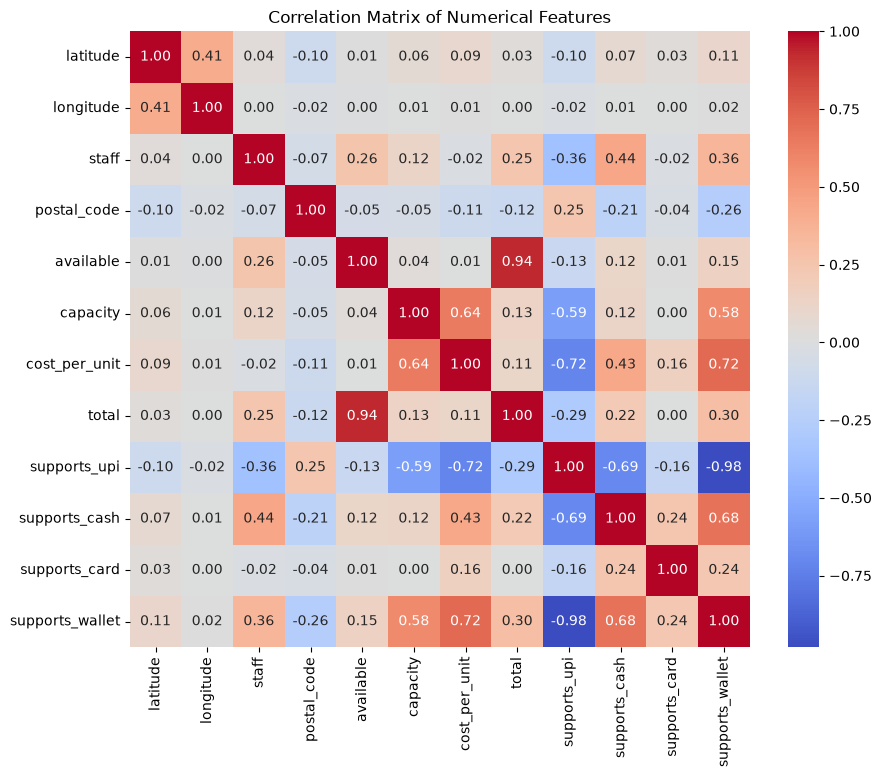

In [134]:
corr_df = numeric_df.drop(columns=["payment_methods"])

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [135]:
import folium

In [136]:
delhi_map = folium.Map(
    location=[28.6139, 77.2090],
    zoom_start=11
)

In [137]:
for i, row in delhi_df.iterrows():
    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=row["name"]
    ).add_to(delhi_map)

delhi_map

In [138]:
delhi_df[["open", "close"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 2229 entries, 0 to 2228
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   open    2229 non-null   str  
 1   close   2229 non-null   str  
dtypes: str(2)
memory usage: 35.0 KB


In [139]:
print(delhi_df["open"].value_counts().sort_index())

open
00:00        145
00:00:00    2033
06:00:00      47
08:00:00       2
10:00:00       2
Name: count, dtype: int64


In [140]:
print(delhi_df["close"].value_counts().sort_index())

close
00:00:00    1858
20:00:00       4
22:00:00      47
23:59        145
23:59:59     175
Name: count, dtype: int64


In [141]:
delhi_df["open"] = pd.to_datetime(delhi_df["open"], format="mixed")
delhi_df["close"] = pd.to_datetime(delhi_df["close"], format="mixed")

In [143]:
delhi_df.groupby(["open", "close"]).size().sort_values(ascending=False)

open                 close              
2026-07-25 00:00:00  2026-07-25 00:00:00    1858
                     2026-07-25 23:59:59     175
                     2026-07-25 23:59:00     145
2026-07-25 06:00:00  2026-07-25 22:00:00      47
2026-07-25 08:00:00  2026-07-25 20:00:00       2
2026-07-25 10:00:00  2026-07-25 20:00:00       2
dtype: int64

In [144]:
delhi_df["is_24x7"] = (
    (delhi_df["open"].dt.strftime("%H:%M") == "00:00") &
    (
        (delhi_df["close"].dt.strftime("%H:%M") == "23:59") |
        (delhi_df["close"].dt.strftime("%H:%M:%S") == "23:59:59")
    )
).astype(int)

In [145]:
delhi_df.to_csv("../data/processed/cleaned_delhi_ev_data.csv", index=False)